In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import matplotlib.pyplot as plt
import numpy as np
from few.utils.constants import YRSID_SI

import seaborn as sns

# Error on 0PA Fluxes, 1PA Fluxes, 1PA Energy as a result of down sampling

In [3]:
ode = Trajectory1PAT1R()

In [5]:
ode = Trajectory1PAT1R()

ode_downsampled = Trajectory1PAT1R(downsample={
    'Flux/Energy/0PA/Infinity': 4,
    'Flux/Energy/0PA/Horizon': 4,
    'Flux/AngularMomentum/0PA/Horizon': 1,
    'Flux/Energy/1PA/Infinity': 4,
    'Flux/Energy/1PAchi1/Infinity': 1,
    'Flux/Energy/1PAchi1/Horizon': 1,
    'Flux/Energy/1PAchi2/Infinity': 1,
    'Flux/Energy/1PAchi2/Horizon': 1,
    'Energy/1PA/dEdOmega': 4})

In [7]:
p_values = np.linspace(6.25, 20.0, 1000)

FluxInf0PA_values = np.array([ode.interpolant['Flux/Energy/0PA/Infinity'](p) for p in p_values])
FluxInf0PA_values_downsample = np.array([ode_downsampled.interpolant['Flux/Energy/0PA/Infinity'](p) for p in p_values])
FluxInf0PA_RelativeError = np.abs(FluxInf0PA_values - FluxInf0PA_values_downsample) / np.abs(FluxInf0PA_values)

FluxInf1PA_values = np.array([ode.interpolant['Flux/Energy/1PA/Infinity'](p) for p in p_values])
FluxInf1PA_values_downsample = np.array([ode_downsampled.interpolant['Flux/Energy/1PA/Infinity'](p) for p in p_values])
FluxInf1PA_RelativeError = np.abs(FluxInf1PA_values - FluxInf1PA_values_downsample) / np.abs(FluxInf1PA_values)

Energy1PA_values = np.array([ode.interpolant['Energy/1PA/dEdOmega'](p) for p in p_values])
Energy1PA_values_downsample = np.array([ode_downsampled.interpolant['Energy/1PA/dEdOmega'](p) for p in p_values])
Energy1PA_RelativeError = np.abs(Energy1PA_values - Energy1PA_values_downsample) / np.abs(Energy1PA_values)

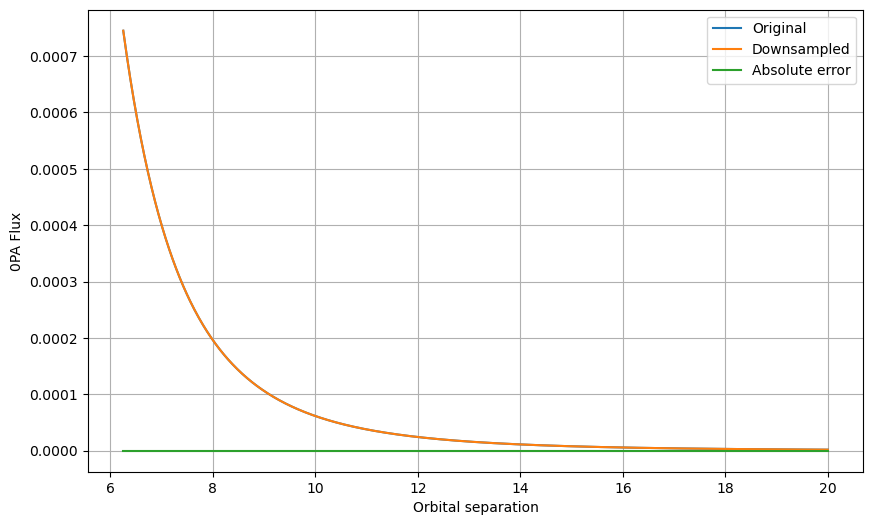

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(p_values, FluxInf0PA_values, label="Original")
plt.plot(p_values, FluxInf0PA_values_downsample, label="Downsampled")
plt.plot(p_values, FluxInf0PA_values-FluxInf0PA_values_downsample, label="Absolute error")
plt.xlabel("Orbital separation")
plt.ylabel("0PA Flux")
plt.grid()
plt.legend()
plt.show()

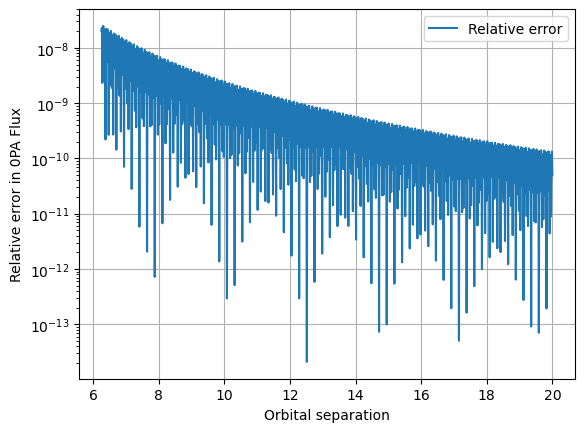

In [10]:
plt.plot(p_values, FluxInf0PA_RelativeError, label="Relative error")
plt.xlabel("Orbital separation")
plt.ylabel("Relative error in 0PA Flux")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

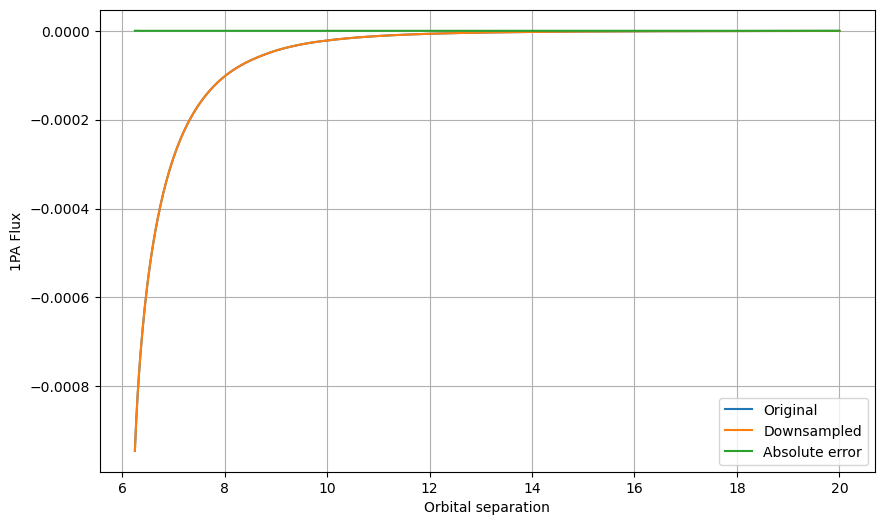

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(p_values, FluxInf1PA_values, label="Original")
plt.plot(p_values, FluxInf1PA_values_downsample, label="Downsampled")
plt.plot(p_values, FluxInf1PA_values-FluxInf1PA_values_downsample, label="Absolute error")
plt.xlabel("Orbital separation")
plt.ylabel("1PA Flux")
plt.grid()
plt.legend()
plt.show()


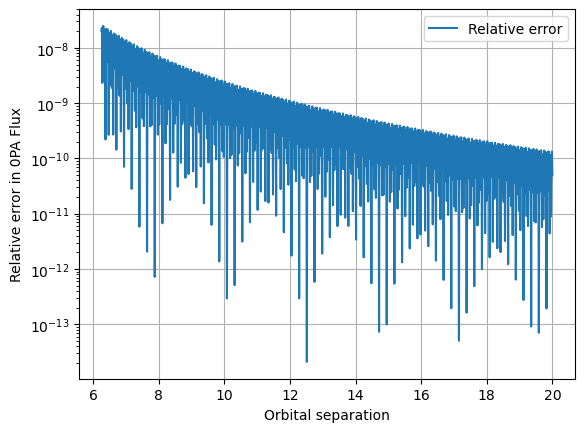

In [12]:
plt.plot(p_values, FluxInf0PA_RelativeError, label="Relative error")
plt.xlabel("Orbital separation")
plt.ylabel("Relative error in 0PA Flux")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

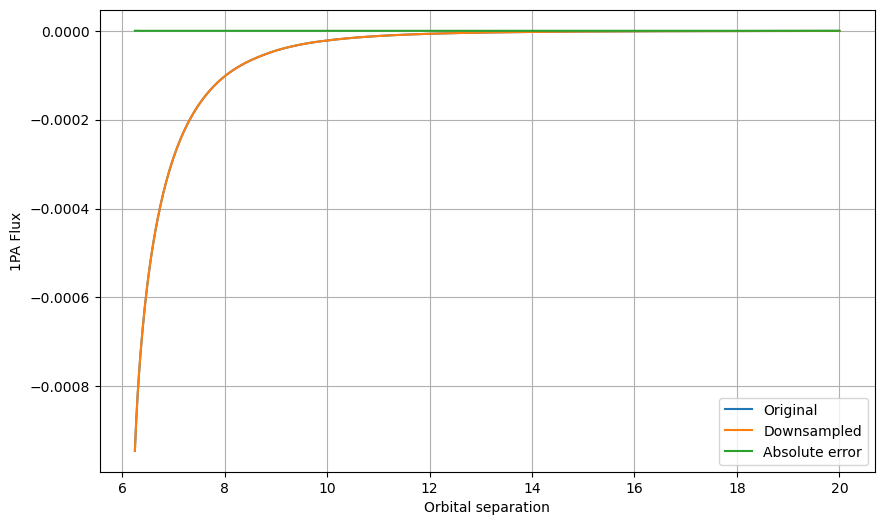

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(p_values, FluxInf1PA_values, label="Original")
plt.plot(p_values, FluxInf1PA_values_downsample, label="Downsampled")
plt.plot(p_values, FluxInf1PA_values-FluxInf1PA_values_downsample, label="Absolute error")
plt.xlabel("Orbital separation")
plt.ylabel("1PA Flux")
plt.grid()
plt.legend()
plt.show()

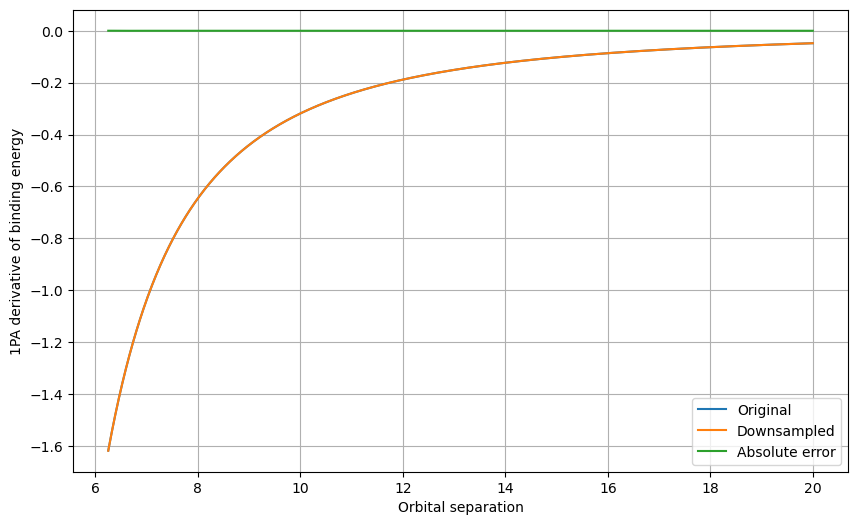

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(p_values, Energy1PA_values, label="Original")
plt.plot(p_values, Energy1PA_values_downsample, label="Downsampled")
plt.plot(p_values, Energy1PA_values-Energy1PA_values_downsample, label="Absolute error")
plt.xlabel("Orbital separation")
plt.ylabel("1PA derivative of binding energy")
plt.grid()
plt.legend()
plt.show()


# Dephasing Due to downsampling 0PA Terms

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from few.trajectory.inspiral import EMRIInspiral
from tqdm import tqdm
from numpy.random import seed, uniform, randint
import time

from few.utils.constants import YRSID_SI

#Importing Flux Trajectory
from few.trajectory.ode import Trajectory1PAT1R
from few.utils.utility import get_p_at_t

from few.utils.geodesic import get_separatrix

In [15]:
full_flux = EMRIInspiral(func=Trajectory1PAT1R)

In [17]:
skip_points = 2
downsampled_2 = EMRIInspiral(func=Trajectory1PAT1R, downsample={
    'Flux/Energy/0PA/Infinity': skip_points,
    'Flux/Energy/0PA/Horizon': skip_points,})


skip_points = 4
downsampled_4 = EMRIInspiral(func=Trajectory1PAT1R, downsample={
    'Flux/Energy/0PA/Infinity': skip_points,
    'Flux/Energy/0PA/Horizon': skip_points,})

skip_points = 8
downsampled_8 = EMRIInspiral(func=Trajectory1PAT1R, downsample={
    'Flux/Energy/0PA/Infinity': skip_points,
    'Flux/Energy/0PA/Horizon': skip_points,})



### Single Inspiral Example

In [37]:
ode = Trajectory1PAT1R()

ode.separatrix_buffer_dist

0.01

In [38]:
m1 = 1e6       # primary mass [solar masses]
m2 = 10       # secondary mass [solar masses]

a  = -0.075       # primary spin chi1 (dimensionless)
chi2  = 0.1   # secondary spin
p0 = 10.0      # initial orbital separation [M]

e0 = 0.

x0 = 1.

dt = 1.   # time step [s]
T  = 1    # total duration [yr]

traj_args = [m1,m2,a,p0,e0,x0,chi2] 


In [39]:
get_separatrix(a,e0,x0)

6.24284067364837

In [40]:
traj_args = [m1,m2,a,e0,x0,chi2] 

bounds = [ode.min_p()+ode.separatrix_buffer_dist, ode.max_p()]

p0 = get_p_at_t(full_flux, T,traj_args,bounds = bounds)
p0

9.625298511651073

In [44]:
# Jonathan's randomised parameters code

def gen_parameters(NEVAL, duration, seed_in=314159):

    traj_module = EMRIInspiral(func=Trajectory1PAT1R)

    M_range = [1E5, 1E7]
    mu_range = [1,1E2]
    a_range = [-0.075, 0.2]
    chi2_range = [-1, 1]

    e0 = 0.0  # will be ignored in circular waveform
    x0 = 1.0  # will be ignored in Schwarzschild waveform

    _base_params = [
        1E5, # M
        10,  # mu
        0.0, # a
        0.0, # p0
        0.0, # e0
        x0,  # x0
        0.0, # chi2
    ]

    seed(seed_in)
    M_seed, mu_seed, a_seed, chi2_seed = randint(1E3, 1E5, size=4)

    seed(M_seed)
    M_list = uniform(low=M_range[0], high=M_range[1], size=NEVAL)
    seed(mu_seed)
    mu_list = uniform(low=mu_range[0], high=mu_range[1], size=NEVAL)
    seed(a_seed)
    a_list = uniform(low=a_range[0], high=a_range[1], size=NEVAL)
    seed(chi2_seed)
    chi2_list = uniform(low=chi2_range[0], high=chi2_range[1], size=NEVAL)

    output_params_list = []
    failed_params_list = []

    for i, (M, mu, a, chi2) in enumerate(zip(
        M_list,
        mu_list,
        a_list,
        chi2_list,  
    )):

        try:
            # print(f"{i+1}:\t{M}, {mu}, {a}, {e}")
            updated_params = _base_params.copy()

            updated_params[0] = M
            updated_params[1] = mu
            updated_params[2] = a
            updated_params[6] = chi2
            updated_params[3] = get_p_at_t(
                traj_module,
                1.01*duration,
                [updated_params[0], updated_params[1], updated_params[2], e0, x0,updated_params[6]],
                bounds = [ode.min_p()+ode.separatrix_buffer_dist, ode.max_p()],
                index_of_p=3,
                index_of_a=2,
                index_of_e=4,
                index_of_x=5,
                traj_kwargs={},
                xtol=2e-6,
                rtol=8.881784197001252e-6,
            )

            output_params_list.append(
                updated_params.copy()
            )
        except ValueError:
            failed_params_list.append([M, mu, a, e0, chi2, duration])

    return output_params_list, failed_params_list

In [45]:
traj_pars = gen_parameters(1000, 4.0, seed_in=314159)[0]

In [46]:
len(traj_pars)

980

In [47]:
dephasings = np.zeros([len(traj_pars),6])

for i in range(len(traj_pars)):

    # print(f"Trajectory {i+1} of {len(traj_pars)}")
    t, p, e, xI, Phi_phi, Phi_theta, Phi_r, dM, da  = full_flux(*traj_pars[i], T=T,err=1e-12)
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2, dM2, da2  = downsampled_2(*traj_pars[i], T=T,err=1e-12)
    t4, p4, e4, xI4, Phi_phi4, Phi_theta4, Phi_r4, dM4, da4  = downsampled_4(*traj_pars[i], T=T,err=1e-12)
    t8, p8, e8, xI8, Phi_phi8, Phi_theta8, Phi_r8, dM8, da8  = downsampled_8(*traj_pars[i], T=T,err=1e-12)

    dephasings[i,0] = np.log10(np.abs(Phi_phi[-1] - Phi_phi2[-1]))
    dephasings[i,1] = np.log10(np.abs(Phi_phi[-1] - Phi_phi4[-1]))
    dephasings[i,2] = np.log10(np.abs(Phi_phi[-1] - Phi_phi8[-1]))

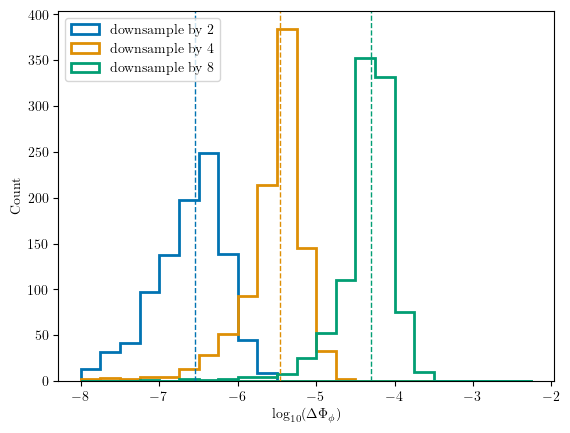

In [53]:
# Plotting the histogram of dephasings
bins1 = np.arange(-8.0,-2.0,0.25)
import seaborn as sns
colorblind_palette = sns.color_palette('colorblind')
import matplotlib.colors as mcolors

colorblind_hex = [mcolors.to_hex(color) for color in colorblind_palette]

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

plt.hist(dephasings[:,0], bins=bins1, histtype='stepfilled', facecolor='none', edgecolor=colorblind_hex[0], linewidth=2, label="downsample by $2$")
plt.hist(dephasings[:,1], bins=bins1, histtype='stepfilled',facecolor='none', edgecolor=colorblind_hex[1], linewidth=2, label="downsample by $4$")
plt.hist(dephasings[:,2], bins=bins1, histtype='stepfilled',facecolor='none', edgecolor=colorblind_hex[2], linewidth=2, label="downsample by $8$")

# Compute medians
median1 = np.median(dephasings[:,0])
median2 = np.median(dephasings[:,1])
median3 = np.median(dephasings[:,2])

# Add vertical lines at the medians
plt.axvline(median1, color=colorblind_hex[0], linestyle='dashed', linewidth=1)
plt.axvline(median2, color=colorblind_hex[1], linestyle='dashed', linewidth=1)
plt.axvline(median3, color=colorblind_hex[2], linestyle='dashed', linewidth=1)


plt.xlabel(r'$\log_{10}(\Delta \Phi_{\phi})$')
plt.ylabel("Count")
#plt.title("Dephasing after 4 years as a function of downsampling factor")
plt.legend()
#plt.savefig("DownsampledFluxesHistogram2.pdf")
plt.show()

## Sampling Across parameter space

In [54]:
skip_points = 2
downsampled_2 = EMRIInspiral(func=Trajectory1PAT1R, downsample={
    'Flux/Energy/1PA/Infinity': skip_points,
    'Flux/Energy/1PAchi1/Infinity': skip_points,
    'Flux/Energy/1PAchi1/Horizon': skip_points,
    'Flux/Energy/1PAchi2/Infinity': skip_points,
    'Flux/Energy/1PAchi2/Horizon': skip_points,
    'Energy/1PA/dEdOmega': skip_points})


skip_points = 4
downsampled_4 = EMRIInspiral(func=Trajectory1PAT1R, downsample={
    'Flux/Energy/1PA/Infinity': skip_points,
    'Flux/Energy/1PAchi1/Infinity': skip_points,
    'Flux/Energy/1PAchi1/Horizon': skip_points,
    'Flux/Energy/1PAchi2/Infinity': skip_points,
    'Flux/Energy/1PAchi2/Horizon': skip_points,
    'Energy/1PA/dEdOmega': skip_points})

skip_points = 8
downsampled_8 = EMRIInspiral(func=Trajectory1PAT1R, downsample={
    'Flux/Energy/1PA/Infinity': skip_points,
    'Flux/Energy/1PAchi1/Infinity': skip_points,
    'Flux/Energy/1PAchi1/Horizon': skip_points,
    'Flux/Energy/1PAchi2/Infinity': skip_points,
    'Flux/Energy/1PAchi2/Horizon': skip_points,
    'Energy/1PA/dEdOmega': skip_points})



In [55]:
dephasings = np.zeros([len(traj_pars),3])

for i in range(len(traj_pars)):

    # print(f"Trajectory {i+1} of {len(traj_pars)}")
    t, p, e, xI, Phi_phi, Phi_theta, Phi_r, dM, da  = full_flux(*traj_pars[i], T=T,err=1e-12)
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2, dM2, da2  = downsampled_2(*traj_pars[i], T=T,err=1e-12)
    t4, p4, e4, xI4, Phi_phi4, Phi_theta4, Phi_r4, dM4, da4  = downsampled_4(*traj_pars[i], T=T,err=1e-12)
    t8, p8, e8, xI8, Phi_phi8, Phi_theta8, Phi_r8, dM8, da8  = downsampled_8(*traj_pars[i], T=T,err=1e-12)

    dephasings[i,0] = np.log10(np.abs(Phi_phi[-1] - Phi_phi2[-1]))
    dephasings[i,1] = np.log10(np.abs(Phi_phi[-1] - Phi_phi4[-1]))
    dephasings[i,2] = np.log10(np.abs(Phi_phi[-1] - Phi_phi8[-1]))

/var/folders/61/zcyl6fqn2sd49qxb8hd1hl740000gn/T/ipykernel_45997/768159900.py:11: RuntimeWarning: divide by zero encountered in log10
  dephasings[i,0] = np.log10(np.abs(Phi_phi[-1] - Phi_phi2[-1]))


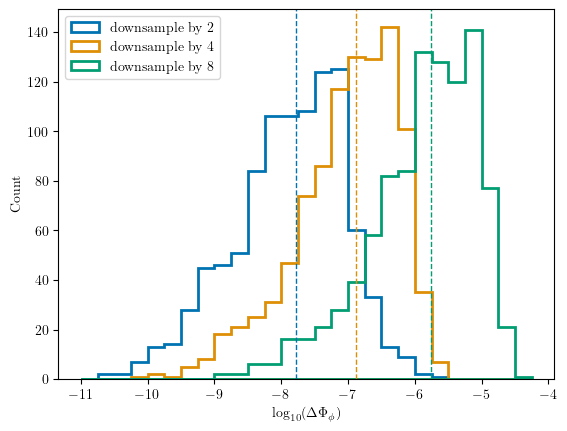

In [61]:
# Plotting the histogram of dephasings
bins1 = np.arange(-11.0,-4.0,0.25)
import seaborn as sns
colorblind_palette = sns.color_palette('colorblind')
import matplotlib.colors as mcolors

colorblind_hex = [mcolors.to_hex(color) for color in colorblind_palette]

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

plt.hist(dephasings[:,0], bins=bins1, histtype='stepfilled', facecolor='none', edgecolor=colorblind_hex[0], linewidth=2, label="downsample by $2$")
plt.hist(dephasings[:,1], bins=bins1, histtype='stepfilled',facecolor='none', edgecolor=colorblind_hex[1], linewidth=2, label="downsample by $4$")
plt.hist(dephasings[:,2], bins=bins1, histtype='stepfilled',facecolor='none', edgecolor=colorblind_hex[2], linewidth=2, label="downsample by $8$")

# Compute medians
median1 = np.median(dephasings[:,0])
median2 = np.median(dephasings[:,1])
median3 = np.median(dephasings[:,2])

# Add vertical lines at the medians
plt.axvline(median1, color=colorblind_hex[0], linestyle='dashed', linewidth=1)
plt.axvline(median2, color=colorblind_hex[1], linestyle='dashed', linewidth=1)
plt.axvline(median3, color=colorblind_hex[2], linestyle='dashed', linewidth=1)


plt.xlabel(r'$\log_{10}(\Delta \Phi_{\phi})$')
plt.ylabel("Count")
#plt.title("Dephasing after 4 years as a function of downsampling factor")
plt.legend()
#plt.savefig("DownsampledFluxesHistogram2.pdf")
plt.show()

# Dephasing Due to downsampling 1PA Terms